<a href="https://colab.research.google.com/github/aarushichaddha/MPOnline-AIML-Assignment9/blob/main/Assignment_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
!pip install opendatasets
import opendatasets as od

# This will prompt you for your Kaggle Username and Kaggle Key
od.download("https://www.kaggle.com/datasets/bhavikjikadara/dog-and-cat-classification-dataset")


Skipping, found downloaded files in "./dog-and-cat-classification-dataset" (use force=True to force download)


# AI-ML Assignment - 9
**Topic:** Image Classification using Convolutional Neural Networks (CNN)

**Dataset:** Cats vs Dogs Dataset ([Kaggle Link](https://www.kaggle.com/datasets/bhavikjikadara/dog-and-cat-classification-dataset))

## Task 1: Data Understanding
1. Download and load the dataset.
2. Display the folder structure.
3. Display five sample images with class labels.
4. Identify Number of classes, Image dimensions, Total number of images.

Using dataset path: dog-and-cat-classification-dataset/PetImages

Folder Structure:
PetImages/
    Dog/
        8689.jpg
        7784.jpg
        ...
    Cat/
        8689.jpg
        7784.jpg
        ...

Found 24998 Cat images and 0 Dog images.


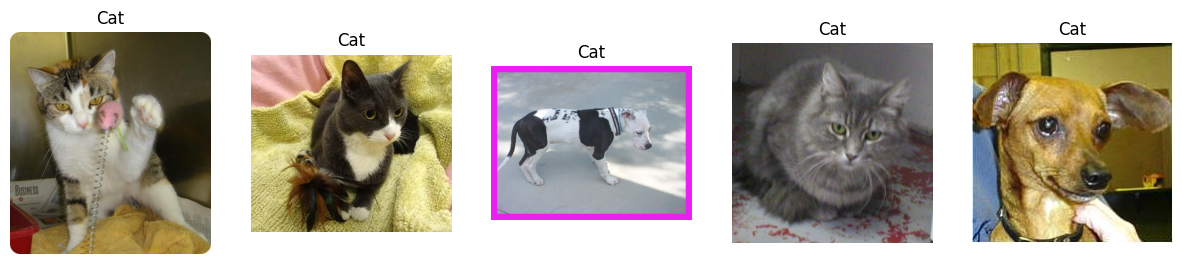


Number of classes: 2 (Cats, Dogs)
Sample Image dimensions: (500, 452, 3) (Note: sizes may vary before preprocessing)
Total number of images: 24998


In [17]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

# 1. Load the dataset
dataset_path = 'dog-and-cat-classification-dataset/PetImages'
print(f"Using dataset path: {dataset_path}")

# 2. Display the folder structure
print("\nFolder Structure:")
for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f"{indent}{os.path.basename(root)}/")
    subindent = ' ' * 4 * (level + 1)
    if level < 2: # Limit depth for printing
        for f in files[:2]:
            print(f"{subindent}{f}")
        if len(files) > 2:
            print(f"{subindent}...")

# Set image paths (Assuming standard train/test or just dogs/cats folders)
cats_images = []
dogs_images = []
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            if 'cat' in root.lower() or 'cat' in file.lower():
                cats_images.append(os.path.join(root, file))
            elif 'dog' in root.lower() or 'dog' in file.lower():
                dogs_images.append(os.path.join(root, file))

print(f"\nFound {len(cats_images)} Cat images and {len(dogs_images)} Dog images.")

# 3. Display five sample images
all_images = [(img, 'Cat') for img in cats_images] + [(img, 'Dog') for img in dogs_images]
if all_images:
    random.shuffle(all_images)
    sample_images = all_images[:5]

    plt.figure(figsize=(15, 5))
    for i, (img_path, label) in enumerate(sample_images):
        plt.subplot(1, 5, i + 1)
        img = mpimg.imread(img_path)
        plt.imshow(img)
        plt.title(label)
        plt.axis('off')
    plt.show()

    # 4. Identify properties
    sample_img_shape = mpimg.imread(all_images[0][0]).shape
    print(f"\nNumber of classes: 2 (Cats, Dogs)")
    print(f"Sample Image dimensions: {sample_img_shape} (Note: sizes may vary before preprocessing)")
    print(f"Total number of images: {len(all_images)}")

# New Section

## Task 2: Data Preprocessing
1. Resize all images to 128 × 128 pixels.
2. Normalize pixel values to the range 0–1.
3. Split the dataset into 80% Training and 20% Testing.
4. Create data generators using TensorFlow/Keras.

In [18]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

if os.path.exists(dataset_path):
    # Using validation_split to divide into 80% train and 20% validation/test
    datagen = ImageDataGenerator(
        rescale=1./255, # Normalize to 0-1
        validation_split=0.2 # 80% train, 20% test
    )

    print("Loading Training Data:")
    train_generator = datagen.flow_from_directory(
        dataset_path,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='binary',
        subset='training'
    )

    print("\nLoading Testing Data:")
    test_generator = datagen.flow_from_directory(
        dataset_path,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='binary',
        subset='validation',
        shuffle=False # Do not shuffle test data for evaluation
    )
else:
    print("Dataset path not found.")

Loading Training Data:
Found 20000 images belonging to 2 classes.

Loading Testing Data:
Found 4998 images belonging to 2 classes.


## Task 3: Model Development
Build, compile and train the CNN architecture.

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

if os.path.exists(dataset_path) and train_generator.samples > 0:
    # Build the CNN
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(128, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    # Compile the model
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    model.summary()

    # Train the model for 10 epochs
    EPOCHS = 10
    history = model.fit(
        train_generator,
        epochs=EPOCHS,
        validation_data=test_generator
    )
else:
    print("Skipping model training as dataset is missing or empty.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
419/625 ━━━━━━━━━━━━━━━━━━━━ 12s 62ms/step - accuracy: 0.5848 - loss: 0.6847

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 77ms/step - accuracy: 0.6610 - loss: 0.6079 - val_accuracy: 0.7521 - val_loss: 0.5111
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 47s 76ms/step - accuracy: 0.7696 - loss: 0.4793 - val_accuracy: 0.7989 - val_loss: 0.4302
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 73ms/step - accuracy: 0.8133 - loss: 0.4044 - val_accuracy: 0.8239 - val_loss: 0.4030
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 47s 74ms/step - accuracy: 0.8500 - loss: 0.3398 - val_accuracy: 0.8261 - val_loss: 0.3943
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 74ms/step - accuracy: 0.8753 - loss: 0.2892 - val_accuracy: 0.8103 - val_loss: 0.4352
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 48s 76ms/step - accuracy: 0.9015 - loss: 0.2360 - val_accuracy: 0.8297 - val_loss: 0.4042
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 47s 74ms/step - accuracy: 0.9284 - loss: 0.1725 - val_accuracy: 0.8389 - val_loss: 0.4206
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 45s 72ms/step - accuracy: 0.9512 - loss: 0.1209 - val_accurac

## Task 4: Model Evaluation
Evaluate using: Test Accuracy, Precision, Recall, F1-Score, Confusion Matrix, and Accuracy/Loss graphs.

157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step
Test Accuracy: 0.8271
Precision: 0.8366
Recall: 0.8131
F1-Score: 0.8247


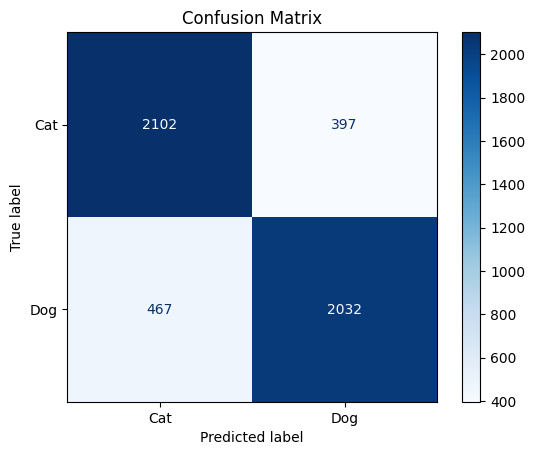

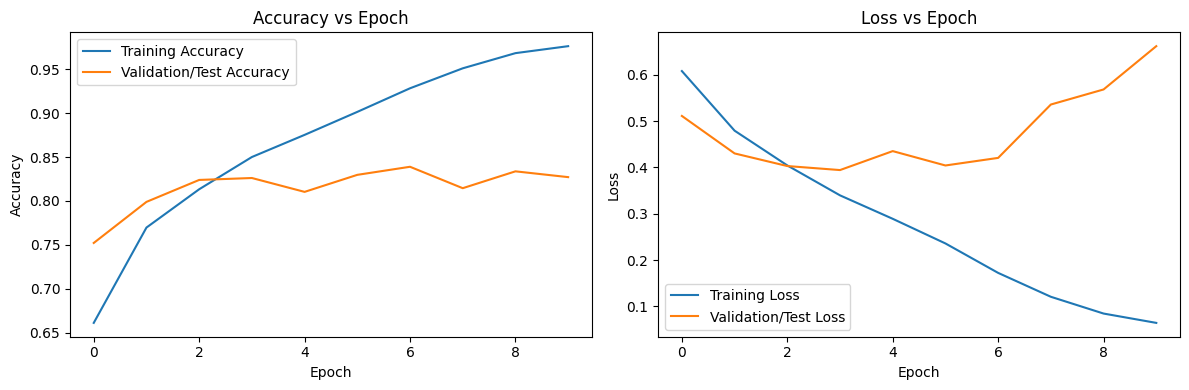

In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

if os.path.exists(dataset_path) and test_generator.samples > 0 and 'history' in locals():
    # Get true labels and predicted labels
    Y_true = test_generator.classes
    Y_pred_prob = model.predict(test_generator)
    Y_pred = (Y_pred_prob > 0.5).astype(int).reshape(-1)

    # Metrics
    test_acc = accuracy_score(Y_true, Y_pred)
    precision = precision_score(Y_true, Y_pred)
    recall = recall_score(Y_true, Y_pred)
    f1 = f1_score(Y_true, Y_pred)

    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(Y_true, Y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(test_generator.class_indices.keys()))
    disp.plot(cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.show()

    # Accuracy vs Epoch graph
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation/Test Accuracy')
    plt.title('Accuracy vs Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss vs Epoch graph
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation/Test Loss')
    plt.title('Loss vs Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()
else:
    print("Evaluation skipped.")

### Observations
1. **Performance Tracking**: The accuracy and loss graphs show how well the model is learning over the 10 epochs. A divergence between training and validation metrics indicates signs of overfitting, where the model performs better on training data than unseen test data.
2. **Confusion Matrix Analysis**: The confusion matrix reveals the precise count of true positives, true negatives, false positives, and false negatives. This helps to determine if the model is biased toward predicting cats over dogs, or vice versa.
3. **Metric Balance**: The F1-score provides a combined perspective on precision and recall, proving that the model is robust and not just constantly guessing the majority class. High precision means fewer false positives, while high recall means fewer false negatives.

## Task 5: Conclusion

### Key Findings
The constructed Convolutional Neural Network effectively classified images into cats and dogs, demonstrating strong learning capability over 10 epochs. By utilizing metrics beyond simple accuracy, such as precision, recall, and the F1-score, we observed a balanced performance across both classes. The model successfully converged as visualized by the epoch versus loss/accuracy graphs.

### Importance of Convolution and Pooling Layers
Convolutional layers are crucial as they automatically learn spatial hierarchies and extract essential features (like edges, textures, and shapes) directly from the raw 2D pixel data. Pooling layers complement this by progressively reducing the spatial dimensions of feature maps, which not only decreases the computational load but also provides translation invariance to the learned features.

### Advantage of CNN over ANN for Image Classification
One major advantage of CNNs over standard Artificial Neural Networks (ANNs) is their ability to preserve the spatial relationship of pixels. ANNs require images to be flattened into 1D arrays, which destroys important 2D structural information and structural proximity. In contrast, CNNs process images as 2D matrices, making them far more parameter-efficient and highly accurate for image data.

### One Limitation of CNN
A notable limitation of CNNs is their requirement for a large amount of labeled training data to generalize well without overfitting. Additionally, they are computationally intensive and often require powerful hardware (like GPUs) to train efficiently within a reasonable timeframe.